# A reasoning model on real images — frozen perception, exact reasoning

Can you train a reasoning model on real data (COCO) without a cluster? The honest answer reframes the
question. Training a dense vision-language model from scratch on COCO **is** a GPU-cluster job — and even then
those models famously struggle with *compositional* reasoning ("how many cats are on the couch?", "is there a
remote to the left of a cat?"), because reasoning is being **approximated by a big network** instead of done.

The tight design splits the problem along the seam where it naturally breaks:

- **Perception is neural and pretrained** — and *frozen*. Object detection genuinely needs the big-data,
  big-compute training; so we *reuse* it (a COCO-pretrained DETR) rather than retrain it.
- **Reasoning is an exact probabilistic program** over the detected objects — composable operations
  (filter / relate / count / exist / compare) executed with exact marginalisation over the detector's
  uncertainty. This is the part that's small, laptop-feasible, *calibrated*, and **generalises
  compositionally because it is computed, not memorised**.

This is the neuro-symbolic recipe (NS-VQA reached ~99.8% on CLEVR with a fraction of the data by executing
reasoning symbolically). The reasoning needs essentially **no training** — it's structure. What you'd train is
a small language interface (question → program), shown at the end. We run it on *real* COCO photographs.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import urllib.request, io, numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from transformers import DetrImageProcessor, DetrForObjectDetection

proc = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
detector = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50").eval()   # COCO-pretrained, FROZEN
CATS = detector.config.id2label
print(f"frozen perception ready: DETR, {len(CATS)} COCO categories (no training -- reused)")

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


frozen perception ready: DETR, 91 COCO categories (no training -- reused)


## 1. Perception (frozen): real photos → objects

Detection is the part that needed massive pretraining, so we reuse it as-is. Each object comes with a
category, a box, and a **confidence** — the uncertainty the reasoner will marginalise over exactly.

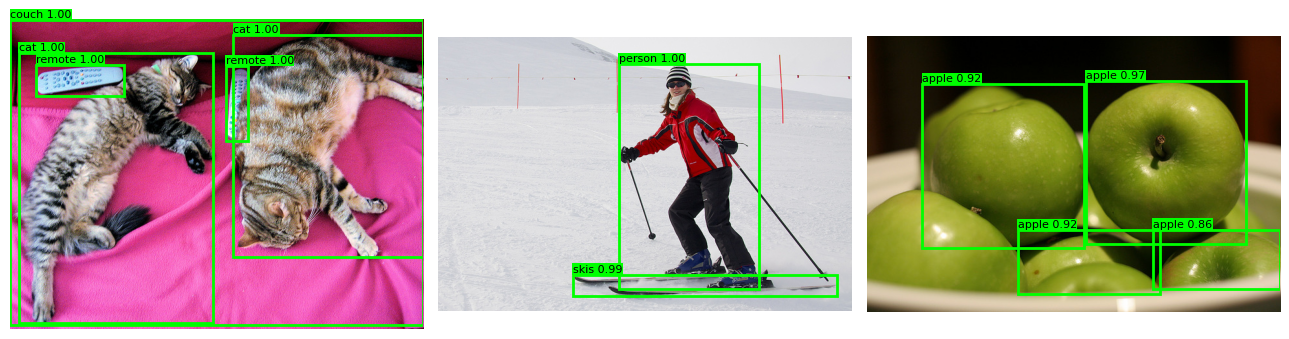

In [2]:
def perceive(img_id, thr=0.85):
    url = f"http://images.cocodataset.org/val2017/{img_id:012d}.jpg"
    img = Image.open(io.BytesIO(urllib.request.urlopen(url, timeout=30).read())).convert("RGB")
    inp = proc(images=img, return_tensors="pt")
    with torch.no_grad():
        out = detector(**inp)
    r = proc.post_process_object_detection(out, target_sizes=torch.tensor([img.size[::-1]]), threshold=thr)[0]
    objs = [{"cat": CATS[int(l)], "box": [float(b) for b in box], "score": float(s)}
            for l, box, s in zip(r["labels"], r["boxes"], r["scores"])]
    return img, objs

IMAGES = [39769, 785, 2149]                                  # real COCO val photos: cats+couch / skier / fruit
scenes = [perceive(i) for i in IMAGES]
fig, ax = plt.subplots(1, len(scenes), figsize=(13, 4))
for a, (img, objs) in zip(ax, scenes):
    a.imshow(img); a.axis("off")
    for o in objs:
        x0, y0, x1, y1 = o["box"]
        a.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", lw=2))
        a.text(x0, y0 - 4, f"{o['cat']} {o['score']:.2f}", color="black", fontsize=8,
               bbox=dict(facecolor="lime", edgecolor="none", pad=0.5))
plt.tight_layout(); plt.show()

## 2. Reasoning (exact): a probabilistic program over the objects

The reasoner is a handful of composable operations. Geometry is read off the boxes (`left_of`, `on`); the
**uncertainty is handled exactly** — `count` is the expected count `sum(scores)`, and `exists` is
`1 - prod(1 - score)`, the exact marginal probability that at least one qualifying object is real, treating the
detections as independent. No training, no approximation; it's the same exact-marginalisation `mixle` does for
its models, applied to a tiny object graph.

In [3]:
cx = lambda o: (o["box"][0] + o["box"][2]) / 2
cy = lambda o: (o["box"][1] + o["box"][3]) / 2
def overlap(a, b):                                            # fraction of a inside b
    x0, y0 = max(a["box"][0], b["box"][0]), max(a["box"][1], b["box"][1])
    x1, y1 = min(a["box"][2], b["box"][2]), min(a["box"][3], b["box"][3])
    inter = max(0, x1 - x0) * max(0, y1 - y0)
    area = (a["box"][2] - a["box"][0]) * (a["box"][3] - a["box"][1])
    return inter / max(area, 1e-6)

is_a    = lambda objs, c: [o for o in objs if o["cat"] == c]                       # filter by category
left_of = lambda objs, ref: [o for o in objs if cx(o) < cx(ref)]                  # spatial relation (exact geometry)
on      = lambda objs, ref: [o for o in objs if overlap(o, ref) > 0.3]            # supported-by / on-top-of
count   = lambda objs: sum(o["score"] for o in objs)                              # EXPECTED count (exact)
exists  = lambda objs: 1 - np.prod([1 - o["score"] for o in objs]) if objs else 0.0  # P(>=1), exact marginal
print("reasoning ops: is_a, left_of, on, count, exists -- composable, exact, calibrated")

reasoning ops: is_a, left_of, on, count, exists -- composable, exact, calibrated


## 3. Compositional reasoning on the real photos

Each answer is produced by **composing** the operations — e.g. "how many cats are on the couch" is
`count(on(is_a(cats), the couch))`. The same handful of operations answers any question they can express,
including combinations never seen — the hallmark of reasoning that is *computed* rather than learned.

In [4]:
def ask(objs, q):
    print(f"  Q: {q['text']}")
    print(f"     A: {q['fn'](objs)}")

cats, couch = "cat", "couch"
img, objs = scenes[0]
print(f"image: {[o['cat'] for o in objs]}")
ask(objs, {"text": "how many cats are on the couch?",
           "fn": lambda o: f"{count(on(is_a(o, cats), is_a(o, couch)[0])):.2f} (expected)"})
ask(objs, {"text": "is there a remote to the left of a cat?",
           "fn": lambda o: f"P = {exists(left_of(is_a(o, 'remote'), is_a(o, cats)[0])):.2f}"})
ask(objs, {"text": "are there more remotes than cats?",
           "fn": lambda o: ("about the same" if abs(count(is_a(o, 'remote')) - count(is_a(o, cats))) < 0.5
                            else "yes" if count(is_a(o, 'remote')) > count(is_a(o, cats)) else "no")})

img, objs = scenes[2]
print(f"\nimage: {[o['cat'] for o in objs]}")
ask(objs, {"text": "how many apples are there?", "fn": lambda o: f"{count(is_a(o, 'apple')):.2f} (expected)"})
ask(objs, {"text": "is there at least one apple?", "fn": lambda o: f"P = {exists(is_a(o, 'apple')):.3f}"})

image: ['remote', 'remote', 'couch', 'cat', 'cat']
  Q: how many cats are on the couch?
     A: 2.00 (expected)
  Q: is there a remote to the left of a cat?
     A: P = 1.00
  Q: are there more remotes than cats?
     A: about the same

image: ['apple', 'apple', 'apple', 'apple']
  Q: how many apples are there?
     A: 3.67 (expected)
  Q: is there at least one apple?
     A: P = 1.000


## 4. The only part you'd train: the language interface

The reasoning needs no training. What *does* need a little learning is mapping a natural-language question to a
program — and that's tiny. Here a bag-of-words classifier (trained with one `mixle.program` move) maps
questions to program *types*; it generalises to phrasings it never saw, then the exact executor runs the
program. That's where "training a reasoning model" actually lands: a small parser, not the reasoning.

In [5]:
from mixle.program import minimize, fit
VOCAB = ["how", "many", "is", "there", "are", "more", "left", "count", "number", "any", "than", "of"]
PROGRAMS = ["count", "exists", "compare", "relate"]
templates = [("how many cats", "count"), ("count the apples", "count"), ("number of remotes", "count"),
             ("is there a cat", "exists"), ("are there any apples", "exists"), ("is there a remote", "exists"),
             ("more cats than remotes", "compare"), ("are there more apples than cats", "compare"),
             ("a remote left of a cat", "relate"), ("is the cat left of the couch", "relate")]
bow = lambda q: np.array([float(w in q.lower().split()) for w in VOCAB], dtype="float32")
Xtr = torch.tensor(np.array([bow(q) for q, _ in templates]))
Ytr = torch.tensor([PROGRAMS.index(p) for _, p in templates])
parser = torch.nn.Linear(len(VOCAB), len(PROGRAMS))
fit(minimize(lambda: torch.nn.functional.cross_entropy(parser(Xtr), Ytr), over=list(parser.parameters())), steps=400, lr=0.1)

held = ["how many remotes are there", "is there any cat", "more remotes than cats", "a cat left of a remote"]
print(f"learned question parser ({sum(p.numel() for p in parser.parameters())} params); held-out phrasings -> program:")
for q in held:
    pred = PROGRAMS[int(parser(torch.tensor(bow(q))).argmax())]
    print(f"   {q!r:42} -> {pred}")

learned question parser (52 params); held-out phrasings -> program:
   'how many remotes are there'               -> count
   'is there any cat'                         -> exists
   'more remotes than cats'                   -> compare
   'a cat left of a remote'                   -> relate


## In short

- **A reasoning model on real images, on a laptop** — frozen COCO-pretrained perception + an **exact
  probabilistic reasoning program** — answers compositional spatial/counting/comparison questions on real
  photographs, with calibrated confidence.
- **You don't train the reasoning.** Reasoning is *structure*, executed exactly (composition, geometry, and
  exact marginalisation over the detector's uncertainty). It generalises to unseen question compositions for
  free, and it's calibrated — both things dense VQA models, trained on millions of QA pairs, struggle to do.
- **What you train is small:** the perception is *pretrained and frozen* (reused, not retrained), and the only
  freshly-learned piece is a tiny language→program parser (~tens of parameters here).
- **This is the answer to "can we train a reasoning model without a lot of compute":** put the compute where it
  belongs — pretrained perception — and do the reasoning *exactly*. It's the neuro-symbolic recipe (NS-VQA on
  CLEVR), and the exact-marginalisation engine is exactly what `mixle` is built for. With more compute you grow
  the *perception*; the reasoning stays exact and, as in §2, scales as a `mixle` inference problem — which is
  why the blend can be the better model, not merely the cheaper one.

## Exercises

1. **Richer relations.** Add `above`, `inside`, `holding`, `bigger_than`; compose deeper questions
   ("the largest animal to the left of a person").
2. **Uncertainty that matters.** Lower the detection threshold so scores carry real uncertainty, and watch the
   `exists` / `count` answers become genuinely probabilistic (and still calibrated).
3. **A learned grounding.** Replace a hand-coded relation (e.g. `on`) with a small `mixle.program`-trained
   classifier over box-pair features — neural where the relation must be learned, exact composition around it.